# Trabajo final: Aprendizaje supervisado y no supervisado

**Asignatura:** Aprendizaje estadístico y computacional  
**Integrantes:** Ana Chia Koo, Daniel Gonzalez, Betty Rabanal, Diego Rojas y Alberto Tiahuallpa  
**Caso de estudio:** Clasificación del nivel de ingreso y segmentación de países mediante indicadores socioeconómicos  
**Fuente de datos:** World Development Indicators y metadatos de países del Banco Mundial  
**Año de análisis:** 2022

> **Pregunta central:** ¿En qué medida un conjunto de indicadores no monetarios de salud, demografía, urbanización y conectividad permite distinguir países de ingreso alto y, simultáneamente, descubrir perfiles de desarrollo que no dependan de la clasificación oficial de ingreso?


## Introducción

El desarrollo de un país es un fenómeno multidimensional. Aunque la clasificación oficial de ingreso del Banco Mundial se construye a partir del ingreso nacional bruto per cápita, variables como la esperanza de vida, la fecundidad, la mortalidad infantil, el acceso a electricidad, la urbanización, el uso de Internet y el gasto en salud también reflejan diferencias estructurales entre países.

Este trabajo analiza indicadores públicos del Banco Mundial correspondientes a 2022. La base no proviene de una librería incorporada en Python, sino que se obtiene desde la API institucional y se integra mediante el código ISO de cada país. Para evitar circularidad, el PIB per cápita se conserva únicamente como variable descriptiva y no se utiliza como predictor del nivel de ingreso.

El análisis se desarrolla en tres etapas. Primero, se realiza un análisis exploratorio para evaluar calidad, faltantes, consistencia, distribución, correlación y presencia de valores atípicos. Segundo, se comparan modelos de clasificación usando separación estratificada entre entrenamiento y prueba, validación cruzada y métricas apropiadas para clases potencialmente desbalanceadas. Tercero, se aplica aprendizaje no supervisado sin incorporar la variable respuesta, se selecciona el número de grupos mediante inercia y silueta, y se interpretan los perfiles obtenidos.

El propósito no es solo alcanzar un buen desempeño predictivo, sino explicar qué indicadores acompañan con mayor intensidad al nivel de ingreso y detectar agrupaciones de países que revelen similitudes o divergencias frente a la clasificación oficial.


## Objetivos

### Objetivo general
Aplicar técnicas de aprendizaje supervisado y no supervisado a indicadores socioeconómicos de países para predecir la pertenencia al grupo de ingreso alto, identificar perfiles de desarrollo y contrastarlos con la clasificación oficial del Banco Mundial.

### Objetivos específicos
1. Construir una base analítica reproducible mediante la integración de indicadores y metadatos obtenidos desde la API del Banco Mundial.
2. Evaluar la calidad de los datos, examinando faltantes, duplicados, inconsistencias, distribuciones, correlaciones y valores atípicos.
3. Preparar las covariables evitando fuga de información y excluyendo indicadores monetarios del modelado.
4. Comparar modelos de clasificación mediante validación cruzada sobre entrenamiento y métricas adecuadas al posible desbalance de clases.
5. Evaluar una única vez el modelo seleccionado sobre el conjunto de prueba e interpretar sus variables más relevantes.
6. Determinar una cantidad apropiada de clústeres sin utilizar la variable respuesta y describir los perfiles obtenidos.
7. Contrastar los clústeres con el nivel de ingreso oficial para identificar coincidencias y casos atípicos.


## Correspondencia con la rúbrica

- **Contextualización y objetivos:** introducción, pregunta central y objetivos vinculados con la base seleccionada.
- **Análisis exploratorio:** estructura, faltantes, duplicados, inconsistencias, atípicos, distribuciones y correlaciones.
- **Aprendizaje supervisado:** train/test estratificado, comparación con validación cruzada, selección sobre entrenamiento y evaluación final en test.
- **Aprendizaje no supervisado:** exclusión de la respuesta, estandarización, elección de cantidad de grupos e interpretación.
- **Conclusiones:** conexión explícita entre resultados, objetivos, alcances y limitaciones.

> El notebook contiene código, comentarios y celdas Markdown suficientes para explicar cada decisión. El informe escrito debe presentar los resultados sin incluir código.


## 1. Librerías

Se importan todas las librerías que se utilizarán a lo largo del trabajo.


In [2]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage




pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42

## 2. Extracción de los datos desde la API del Banco Mundial

Cada indicador es una llamada aparte a la API, identificado por su código. Se definió una función que trae un indicador para todos los países en un año y devuelve un DataFrame con el código ISO de 3 letras y el valor.


In [3]:
def traer_indicador(codigo, nombre, anio=2022):
    url = f"https://api.worldbank.org/v2/country/all/indicator/{codigo}"
    params = {"format": "json", "date": anio, "per_page": 1000}
    respuesta = requests.get(url, params=params, timeout=60)
    respuesta.raise_for_status()
    contenido = respuesta.json()
    if not isinstance(contenido, list) or len(contenido) < 2 or contenido[1] is None:
        raise RuntimeError(f"Respuesta inesperada de la API para {codigo}")
    rpta = contenido[1]
    df = pd.json_normalize(rpta)[["countryiso3code", "value"]]
    # Los agregados regionales llegan con código vacío; los quito para que el
    # merge por país no genere un producto cartesiano entre indicadores.
    df = df[df["countryiso3code"].str.len() == 3]
    return df.rename(columns={"value": nombre})

# Indicadores no monetarios que uso como covariables
indicadores = {
    "SP.DYN.LE00.IN":     "Esperanza_vida",
    "SP.DYN.TFRT.IN":     "Fecundidad",
    "SP.URB.TOTL.IN.ZS":  "Urbana_pct",
    "IT.NET.USER.ZS":     "Internet_pct",
    "SH.DYN.MORT":        "Mortalidad_u5",
    "SH.XPD.CHEX.GD.ZS":  "Gasto_salud_pctPIB",
    "EG.ELC.ACCS.ZS":     "Acceso_electricidad_pct",
    "SP.POP.TOTL":        "Poblacion",
    "NY.GDP.PCAP.CD":     "PIB_per_capita",
}

frames = [traer_indicador(cod, nom) for cod, nom in indicadores.items()]
print("Indicadores descargados:", len(frames))

Indicadores descargados: 9


Se unieron todos los indicadores en una sola tabla usando el código ISO del país como llave.


In [4]:
from functools import reduce
df = reduce(lambda a, b: a.merge(b, on="countryiso3code", how="outer"), frames)
print(df.shape)
df.head()

(260, 10)


,countryiso3code,Esperanza_vida,Fecundidad,Urbana_pct,Internet_pct,Mortalidad_u5,Gasto_salud_pctPIB,Acceso_electricidad_pct,Poblacion,PIB_per_capita
0,ABW,76.23,1.61,61.88,NaN,NaN,NaN,99.90,"107,310.00","31,000.57"
1,AFE,64.49,4.29,37.36,26.80,63.21,5.57,48.74,"731,821,393.00","1,675.90"
2,AFG,65.62,4.93,25.39,15.87,56.80,23.09,85.30,"40,578,842.00",357.26
3,AFW,57.98,4.56,51.70,37.50,99.28,4.17,55.59,"496,366,058.00","2,143.07"
4,AGO,64.25,5.21,69.05,35.84,51.90,2.60,48.50,"35,635,029.00","3,598.54"


La variable respuesta, el nivel de ingreso, no viene en los indicadores. Para lograrlo, se extrae del endpoint de países, que además trae la región. Ese endpoint mezcla países reales con agregados regionales, así que se extrae la región para filtrarlos después.


In [5]:
url_paises = "https://api.worldbank.org/v2/country"
respuesta_paises = requests.get(url_paises, params={"format": "json", "per_page": 400}, timeout=60)
respuesta_paises.raise_for_status()
contenido_paises = respuesta_paises.json()
if not isinstance(contenido_paises, list) or len(contenido_paises) < 2 or contenido_paises[1] is None:
    raise RuntimeError("Respuesta inesperada del endpoint de países")
rpta = contenido_paises[1]
meta = pd.json_normalize(rpta)[["id", "name", "region.value", "incomeLevel.id", "incomeLevel.value"]]
meta = meta.rename(columns={"id": "countryiso3code", "name": "Pais",
                            "region.value": "Region",
                            "incomeLevel.id": "Ingreso_id",
                            "incomeLevel.value": "Ingreso"})
df = df.merge(meta, on="countryiso3code", how="left")
print(df.shape)
df[["countryiso3code", "Pais", "Region", "Ingreso"]].head()

(260, 14)


,countryiso3code,Pais,Region,Ingreso
0,ABW,Aruba,Latin America & Caribbean,High income
1,AFE,Africa Eastern and Southern,Aggregates,Aggregates
2,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
3,AFW,Africa Western and Central,Aggregates,Aggregates
4,AGO,Angola,Sub-Saharan Africa,Lower middle income


Luego, se filtran los agregados. Los agregados regionales tienen la región marcada como "Aggregates" y el nivel de ingreso como "NA", así que nos quedamos solo con los países reales.


In [6]:
antes = df.shape[0]
df = df[(df["Region"] != "Aggregates") & (df["Ingreso_id"] != "NA")].copy()
df = df.set_index("Pais")
print(f"De {antes} filas quedaron {df.shape[0]} países reales")
df["Ingreso"].value_counts()

De 260 filas quedaron 217 países reales


Ingreso
High income            86
Upper middle income    59
Lower middle income    47
Low income             25
Name: count, dtype: int64

## 3. Análisis exploratorio de datos

Se revisa la estructura, estadísticos y los datos faltantes.


In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 217 entries, Aruba to Zimbabwe
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   countryiso3code          217 non-null    str    
 1   Esperanza_vida           217 non-null    float64
 2   Fecundidad               217 non-null    float64
 3   Urbana_pct               217 non-null    float64
 4   Internet_pct             182 non-null    float64
 5   Mortalidad_u5            196 non-null    float64
 6   Gasto_salud_pctPIB       192 non-null    float64
 7   Acceso_electricidad_pct  215 non-null    float64
 8   Poblacion                217 non-null    float64
 9   PIB_per_capita           209 non-null    float64
 10  Region                   217 non-null    str    
 11  Ingreso_id               217 non-null    str    
 12  Ingreso                  217 non-null    str    
dtypes: float64(9), str(4)
memory usage: 23.7+ KB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Esperanza_vida,217.00,73.11,7.94,18.82,67.79,74.21,78.53,85.75
Fecundidad,217.00,2.41,1.22,0.68,1.51,1.95,3.17,6.25
Urbana_pct,217.00,62.35,23.33,14.69,42.73,63.31,81.16,100.00
Internet_pct,182.00,70.24,25.27,7.14,57.00,78.78,89.50,100.00
Mortalidad_u5,196.00,27.21,38.87,1.40,6.17,14.90,38.80,424.60
Gasto_salud_pctPIB,192.00,6.83,3.37,1.77,4.33,6.55,8.68,23.09
Acceso_electricidad_pct,215.00,87.49,23.16,8.40,86.50,100.00,100.00,100.00
Poblacion,217.00,"36,706,746.19","141,528,692.84","9,992.00","821,637.00","6,664,449.00","26,018,721.00","1,425,423,212.00"
PIB_per_capita,209.00,"21,200.87","31,131.45",301.83,"2,899.16","7,655.59","28,360.30","226,052.06"


### Control de calidad y consistencia

Además de los valores faltantes, se revisan duplicados por país, rangos lógicos e indicadores fuera de escala. Los valores atípicos no se eliminan automáticamente, porque pueden representar diferencias reales entre países; primero se identifican y luego se evalúa su efecto.


In [9]:
# Duplicados y controles de rango
print("Filas duplicadas completas:", df.duplicated().sum())
print("Países duplicados en el índice:", df.index.duplicated().sum())

rangos = {
    "Esperanza_vida": (0, 120),
    "Fecundidad": (0, 15),
    "Urbana_pct": (0, 100),
    "Internet_pct": (0, 100),
    "Mortalidad_u5": (0, None),
    "Gasto_salud_pctPIB": (0, 100),
    "Acceso_electricidad_pct": (0, 100),
}

inconsistencias = {}
for variable, (minimo, maximo) in rangos.items():
    mascara = df[variable].notna() & (df[variable] < minimo)
    if maximo is not None:
        mascara |= df[variable].notna() & (df[variable] > maximo)
    inconsistencias[variable] = int(mascara.sum())

pd.Series(inconsistencias, name="N_inconsistencias").to_frame()


Filas duplicadas completas: 0
Países duplicados en el índice: 0


,N_inconsistencias
Esperanza_vida,0
Fecundidad,0
Urbana_pct,0
Internet_pct,0
Mortalidad_u5,0
Gasto_salud_pctPIB,0
Acceso_electricidad_pct,0


Se cuantifican los datos faltantes por variable.


Internet_pct               35
Gasto_salud_pctPIB         25
Mortalidad_u5              21
PIB_per_capita              8
Acceso_electricidad_pct     2
Urbana_pct                  0
Fecundidad                  0
Esperanza_vida              0
countryiso3code             0
Poblacion                   0
Region                      0
Ingreso_id                  0
Ingreso                     0
dtype: int64


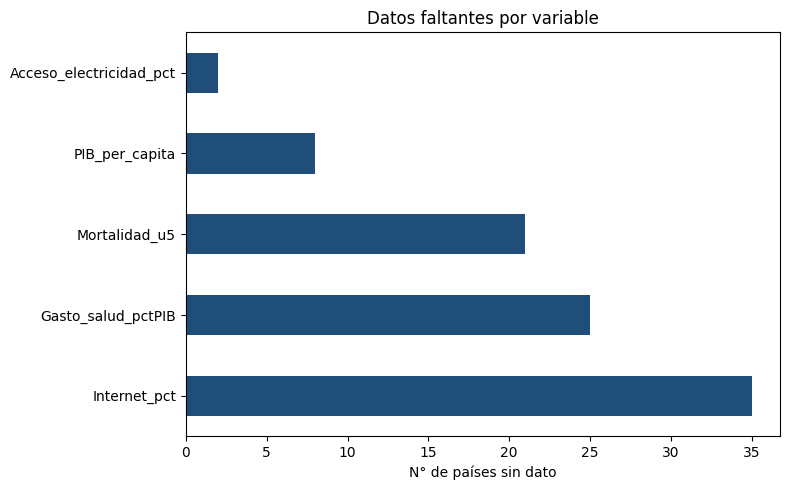

In [10]:
faltantes = df.isna().sum().sort_values(ascending=False)
print(faltantes)
faltantes[faltantes > 0].plot(kind="barh", color="#1F4E78")
plt.title("Datos faltantes por variable")
plt.xlabel("N° de países sin dato")
plt.tight_layout(); plt.show()

Observamos la distribución de las covariables no monetarias con histogramas.


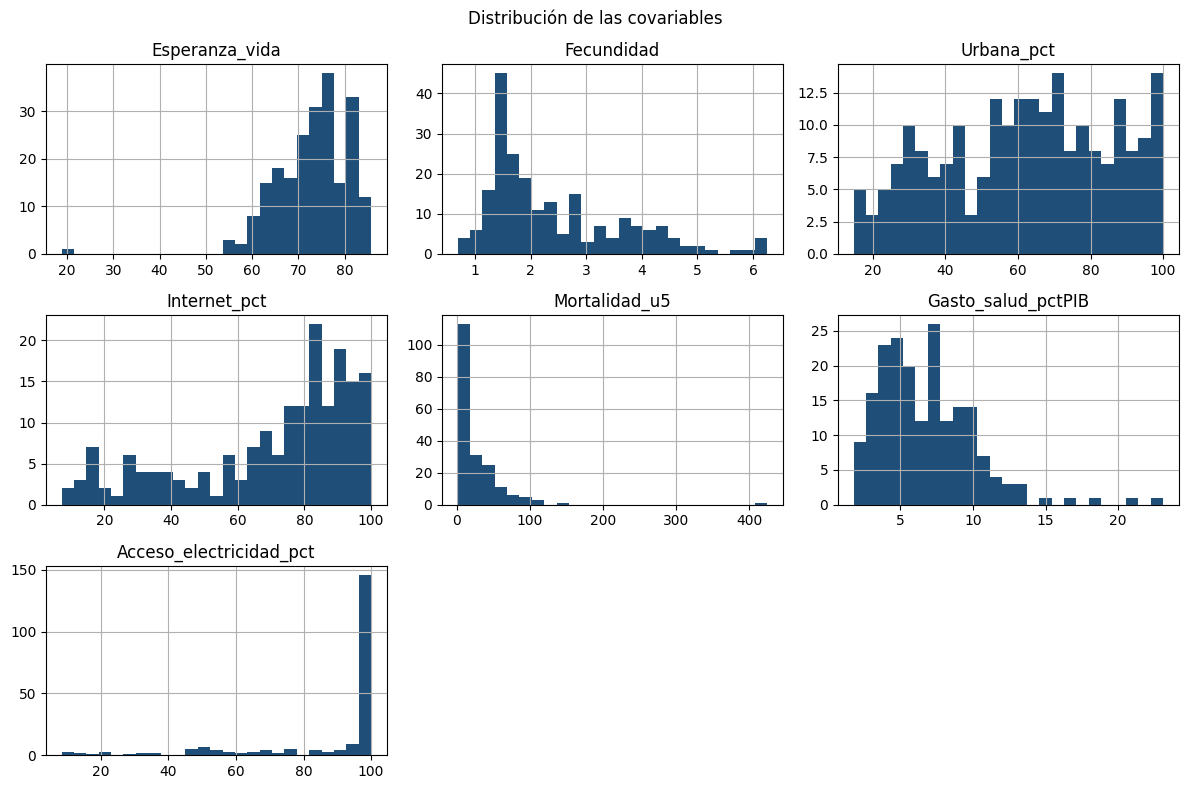

In [11]:
covariables = ["Esperanza_vida", "Fecundidad", "Urbana_pct", "Internet_pct",
               "Mortalidad_u5", "Gasto_salud_pctPIB", "Acceso_electricidad_pct"]
df[covariables].hist(bins=25, figsize=(12, 8), color="#1F4E78")
plt.suptitle("Distribución de las covariables")
plt.tight_layout(); plt.show()

Luego, se revisan las correlaciones entre las covariables para anticipar redundancias.


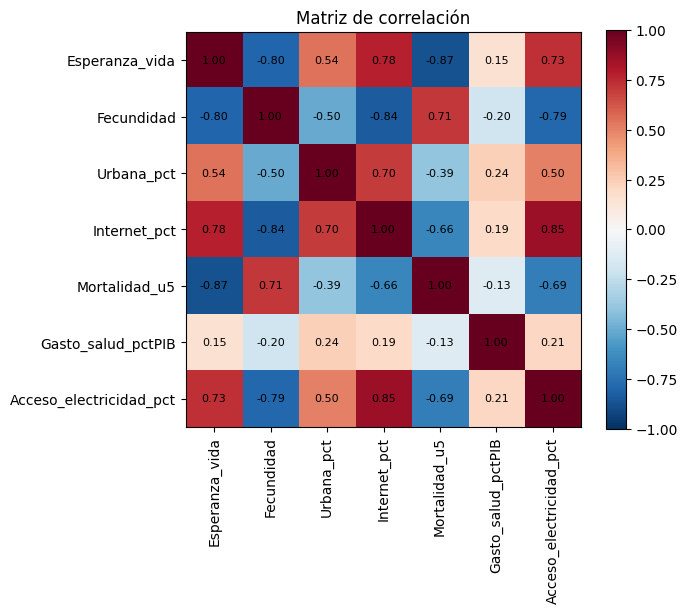

In [12]:
corr = df[covariables].corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(covariables))); ax.set_xticklabels(covariables, rotation=90)
ax.set_yticks(range(len(covariables))); ax.set_yticklabels(covariables)
for i in range(len(covariables)):
    for j in range(len(covariables)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im); plt.title("Matriz de correlación"); plt.tight_layout(); plt.show()

Se revisan los valores atípicos con diagramas de caja sobre las covariables estandarizadas, para poder compararlas en una misma escala.


In [13]:
# No se imputa globalmente antes de separar train y test, porque eso produciría fuga de información.
# La imputación supervisada se ajustará únicamente con X_train.
print("Faltantes pendientes en covariables:", int(df[covariables].isna().sum().sum()))


Faltantes pendientes en covariables: 83


### Tratamiento de datos faltantes

Los datos faltantes se imputan con la mediana. Para evitar fuga de información en el aprendizaje supervisado, el imputador se ajusta exclusivamente con el conjunto de entrenamiento y luego se aplica al conjunto de prueba. En el análisis no supervisado, se ajusta un imputador independiente sobre las covariables utilizadas para formar los clústeres.


In [14]:
# No se realiza imputación global antes de separar train y test.
# La imputación se realizará más adelante utilizando únicamente X_train.

print(
    "Faltantes pendientes en covariables:",
    int(df[covariables].isna().sum().sum())
)

Faltantes pendientes en covariables: 83


## 4. Aprendizaje supervisado

### Variable respuesta

El nivel de ingreso oficial tiene cuatro categorías.
- High income : 86 países
- Upper middle income : 59 países
- Lower middle income : 47 países
- Low income : 25 países


Se optó por una clasificación binaria debido al fuerte desbalance existente entre las categorías originales y porque el interés analítico del estudio se centra en identificar los países que alcanzan el nivel de ingreso alto frente a aquellos que no lo alcanzan.


In [15]:
df["y"] = (df["Ingreso_id"] == "HIC").astype(int)
print(df["y"].value_counts())
print("\nProporción de ingreso alto:", round(df["y"].mean(), 3))

y
0    131
1     86
Name: count, dtype: int64

Proporción de ingreso alto: 0.396


### Variable respuesta y balance de clases

La tarea supervisada es una clasificación binaria: **Ingreso alto** frente a **Resto**. Antes de entrenar se revisa la distribución de clases. Debido a que la exactitud puede ser engañosa si existe desbalance, la selección considera especialmente exactitud balanceada, F1 y ROC-AUC.


In [16]:
y = df["y"]

distribucion_clases = pd.DataFrame({
    "N": y.value_counts().sort_index(),
    "Porcentaje": y.value_counts(normalize=True)
                   .sort_index()
                   .mul(100)
                   .round(2)
})

distribucion_clases.index = ["Resto", "Ingreso alto"]

distribucion_clases


,N,Porcentaje
Resto,131,60.37
Ingreso alto,86,39.63


Se realiza separación de dataset en entrenamiento y prueba de forma estratificada en la variable "y", para conservar la proporción de clases, y se estandarizan las covariables ajustando el escalador solo con el entrenamiento.


In [17]:
X = df[covariables]
y = df["y"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)

imputer = SimpleImputer(strategy="median")
X_train_i = imputer.fit_transform(X_train)
X_test_i = imputer.transform(X_test)

scaler = StandardScaler().fit(X_train_i)
X_train_s = scaler.transform(X_train_i)
X_test_s = scaler.transform(X_test_i)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (151, 7)  Test: (66, 7)


Se entrenaron cuatro modelos de clasificación, realizando validación cruzada estratificada de 5 pliegues.

Se realiza balanceo de clases con `class_weight='balanced'` en 3 de 4 modelos, solo "Gradient Boosting" no lo permite.

Posteriormente, se comparan distintas métricas del modelo, siempre trabajando con el grupo de entrenamiento y el uso de kfold.


In [18]:
modelos = {
    "Regresión logística": LogisticRegression(max_iter=1000,class_weight="balanced"),
    "Árbol de decisión": DecisionTreeClassifier(max_depth=4,class_weight="balanced",random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300,class_weight="balanced",random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

# Se definen parametros para validación cruzada
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)

filas = []
for nombre, modelo in modelos.items():
    # Predicciones out-of-fold sobre el conjunto de entrenamiento
    pred_cv = cross_val_predict(modelo,X_train_s,y_train,cv=cv,method="predict")
    # Probabilidades out-of-fold
    proba_cv = cross_val_predict(modelo,X_train_s,y_train,cv=cv,method="predict_proba")[:, 1]
    filas.append({
        "Modelo": nombre,
        "Exactitud": accuracy_score(y_train, pred_cv),
        "Exactitud balanceada": balanced_accuracy_score(y_train, pred_cv),
        "Precisión": precision_score(y_train, pred_cv),
        "Recall": recall_score(y_train, pred_cv),
        "F1": f1_score(y_train, pred_cv),
        "ROC-AUC": roc_auc_score(y_train, proba_cv),
    })

resultados = (pd.DataFrame(filas).set_index("Modelo").sort_values("F1", ascending=False))

resultados

#Pendiente sacar metricas con promedio de kfold

,Exactitud,Exactitud balanceada,Precisión,Recall,F1,ROC-AUC
Modelo,,,,,,
Random Forest,0.87,0.87,0.84,0.85,0.84,0.94
Regresión logística,0.83,0.84,0.74,0.88,0.80,0.93
Gradient Boosting,0.84,0.83,0.82,0.77,0.79,0.92
Árbol de decisión,0.79,0.78,0.73,0.75,0.74,0.84


Considerando los cálculos de las métricas, se construyen y comparan las curvas ROC de los modelos.


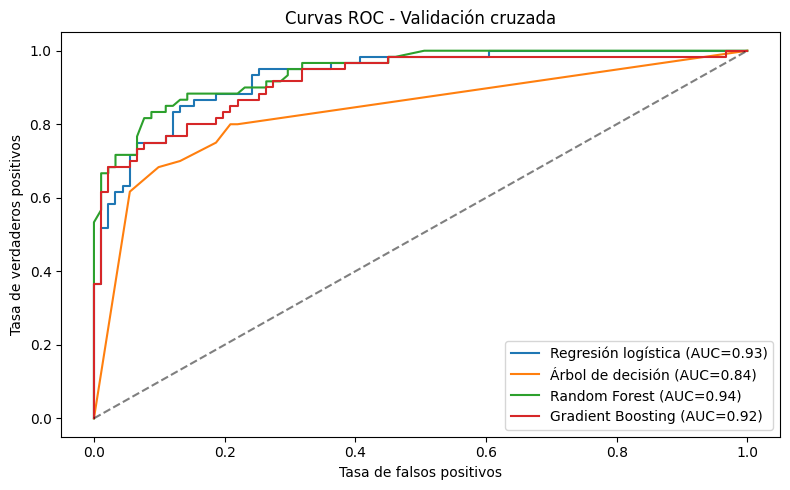

In [19]:
plt.figure()

for nombre, modelo in modelos.items():

    # Probabilidades out-of-fold sobre el conjunto de entrenamiento
    proba_cv = cross_val_predict(modelo,X_train_s,y_train,cv=cv,method="predict_proba")[:, 1]
    fpr, tpr, _ = roc_curve(y_train, proba_cv)
    auc = roc_auc_score(y_train, proba_cv)
    plt.plot(fpr,tpr,label=f"{nombre} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.5)

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curvas ROC - Validación cruzada")
plt.legend()
plt.tight_layout()
plt.show()

### Selección del mejor modelo

Elegimos el modelo con mejor F1, que equilibra precisión y recall bajo el desbalance de clases. Se muestra su matriz de confusión y su reporte de clasificación.


In [20]:
mejor_nombre = resultados.index[0]
mejor = modelos[mejor_nombre]

# Ajuste definitivo del mejor modelo usando todo el conjunto de entrenamiento
mejor.fit(X_train_s, y_train)

print("Mejor modelo:", mejor_nombre)

Mejor modelo: Random Forest


### Probabilidad de corte óptima

En clasificación binaria el umbral estándar de decisión es 0.5.
Para facilitar la interpretación y mantener comparabilidad entre métricas,
se evalúa el modelo utilizando este valor como punto de corte.

Posteriormente se analizan la matriz de confusión,
la precisión, el recall, el F1-score y el ROC-AUC obtenidos en el conjunto de prueba.


In [39]:
# Si no existe un corte calculado previamente,
# usar 0.5 como umbral por defecto
corte = 0.5

proba_test = mejor.predict_proba(X_test_s)[:, 1]

pred_test_opt = (proba_test >= corte).astype(int)

print("\nMatriz de confusión - Test con umbral óptimo:\n",
      confusion_matrix(y_test, pred_test_opt))

print("\nClassification Report - Test con umbral óptimo:\n",
      classification_report(
          y_test,
          pred_test_opt,
          target_names=["Resto", "Ingreso alto"]
      ))


Matriz de confusión - Test con umbral óptimo:
 [[33  7]
 [ 7 19]]

Classification Report - Test con umbral óptimo:
               precision    recall  f1-score   support

       Resto       0.82      0.82      0.82        40
Ingreso alto       0.73      0.73      0.73        26

    accuracy                           0.79        66
   macro avg       0.78      0.78      0.78        66
weighted avg       0.79      0.79      0.79        66



### Variables más influyentes

Reviso qué covariables pesan más en la predicción, según la importancia del modelo elegido.


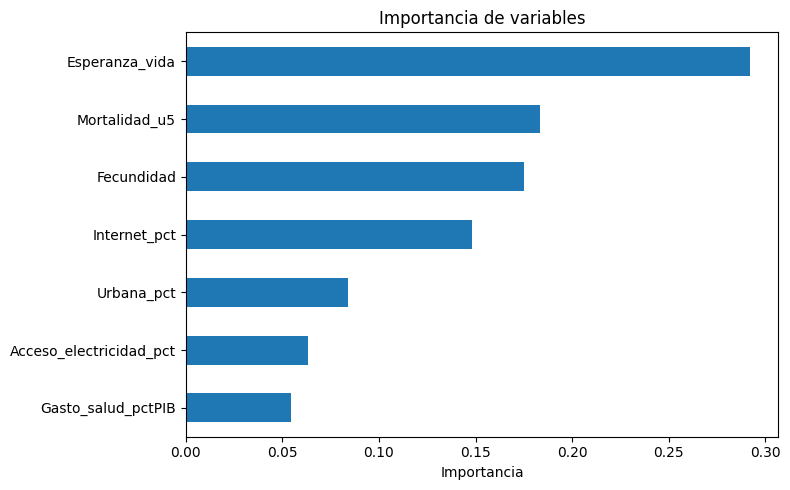

In [22]:
if hasattr(mejor, "feature_importances_"):
    imp = pd.Series(mejor.feature_importances_,index=covariables)
    titulo = "Importancia de variables"
else:
    imp = pd.Series(np.abs(mejor.coef_[0]),index=covariables)
    titulo = "Peso de variables (|coef| regresión logística)"

imp.sort_values().plot(kind="barh")

plt.title(titulo)
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

### Validación de modelo con grupo test

Por ultimo, revisamos las métricas, matriz de validación y variables mas representativas para el grupo test.


In [23]:
# Probabilidades para Test
proba_test = mejor.predict_proba(X_test_s)[:, 1]

# Predicción con umbral 0.5
pred_test_05 = (proba_test >= 0.5).astype(int)

# Predicción con umbral óptimo obtenido en Train
pred_test_opt = (proba_test >= corte).astype(int)

metricas_test = pd.DataFrame({
    "Métrica": [
        "Exactitud",
        "Exactitud balanceada",
        "Precisión",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Umbral 0.5": [
        accuracy_score(y_test, pred_test_05),
        balanced_accuracy_score(y_test, pred_test_05),
        precision_score(y_test, pred_test_05),
        recall_score(y_test, pred_test_05),
        f1_score(y_test, pred_test_05),
        roc_auc_score(y_test, proba_test)
    ],
    "Umbral óptimo": [
        accuracy_score(y_test, pred_test_opt),
        balanced_accuracy_score(y_test, pred_test_opt),
        precision_score(y_test, pred_test_opt),
        recall_score(y_test, pred_test_opt),
        f1_score(y_test, pred_test_opt),
        roc_auc_score(y_test, proba_test)
    ]
})

metricas_test["Umbral 0.5"] = metricas_test["Umbral 0.5"].round(3)
metricas_test["Umbral óptimo"] = metricas_test["Umbral óptimo"].round(3)

metricas_test

,Métrica,Umbral 0.5,Umbral óptimo
0,Exactitud,0.79,0.79
1,Exactitud balanceada,0.78,0.78
2,Precisión,0.73,0.73
3,Recall,0.73,0.73
4,F1,0.73,0.73
5,ROC-AUC,0.91,0.91


Revisamos qué tan bien clasifica


In [24]:
# Predicciones sobre el conjunto de prueba
pred_test = mejor.predict(X_test_s)

print("\nMatriz de confusión - Test:\n",
      confusion_matrix(y_test, pred_test))

print("\nClassification Report - Test:\n",
      classification_report(
          y_test,
          pred_test,
          target_names=["Resto", "Ingreso alto"]
      ))


Matriz de confusión - Test:
 [[33  7]
 [ 7 19]]

Classification Report - Test:
               precision    recall  f1-score   support

       Resto       0.82      0.82      0.82        40
Ingreso alto       0.73      0.73      0.73        26

    accuracy                           0.79        66
   macro avg       0.78      0.78      0.78        66
weighted avg       0.79      0.79      0.79        66



In [25]:
print("Classification Report - Test con umbral óptimo\n")

print(
    classification_report(
        y_test,
        pred_test_opt,
        target_names=["Resto", "Ingreso alto"]
    )
)

Classification Report - Test con umbral óptimo

              precision    recall  f1-score   support

       Resto       0.82      0.82      0.82        40
Ingreso alto       0.73      0.73      0.73        26

    accuracy                           0.79        66
   macro avg       0.78      0.78      0.78        66
weighted avg       0.79      0.79      0.79        66



In [26]:
# Construcción de resultados del conjunto de prueba

test_resultados = X_test.copy()

test_resultados["Real"] = y_test.values
test_resultados["Prediccion"] = pred_test_opt
test_resultados["Probabilidad"] = proba_test

test_resultados["Resultado"] = np.select(
    [
        (test_resultados["Real"] == 1) & (test_resultados["Prediccion"] == 1),
        (test_resultados["Real"] == 0) & (test_resultados["Prediccion"] == 0),
        (test_resultados["Real"] == 0) & (test_resultados["Prediccion"] == 1),
        (test_resultados["Real"] == 1) & (test_resultados["Prediccion"] == 0)
    ],
    [
        "Verdadero positivo",
        "Verdadero negativo",
        "Falso positivo",
        "Falso negativo"
    ],
    default="Sin clasificar"
)

test_resultados.head()

,Esperanza_vida,Fecundidad,Urbana_pct,Internet_pct,Mortalidad_u5,Gasto_salud_pctPIB,Acceso_electricidad_pct,Real,Prediccion,Probabilidad,Resultado
Pais,,,,,,,,,,,
Tanzania,66.88,4.67,34.82,26.86,40.10,3.13,45.80,0,0,0.00,Verdadero negativo
Myanmar,66.51,2.13,30.31,NaN,39.50,4.49,73.70,0,0,0.09,Verdadero negativo
Vanuatu,71.30,3.65,22.25,NaN,17.80,4.06,70.00,0,0,0.03,Verdadero negativo
Guam,77.10,2.82,94.11,NaN,NaN,NaN,100.00,1,1,0.58,Verdadero positivo
Angola,64.25,5.21,69.05,35.84,51.90,2.60,48.50,0,0,0.01,Verdadero negativo


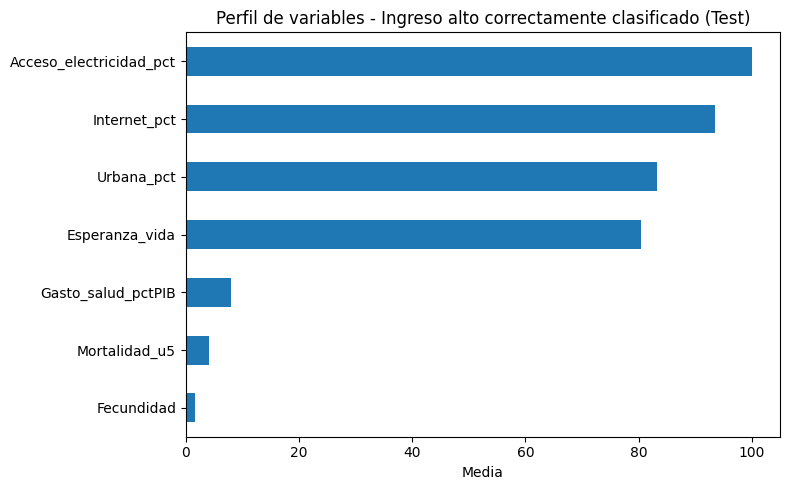

In [27]:
test_tp = test_resultados[
    test_resultados["Resultado"] == "Verdadero positivo"
].copy()

perfil_test = (
    test_tp[covariables]
    .mean()
    .sort_values(ascending=False)
)

perfil_test.sort_values().plot(kind="barh")

plt.title("Perfil de variables - Ingreso alto correctamente clasificado (Test)")
plt.xlabel("Media")
plt.tight_layout()
plt.show()

### Comparativa Train vs Test


In [28]:
# Métricas Train usando el umbral óptimo
proba_train = mejor.predict_proba(X_train_s)[:, 1]
pred_train_opt = (proba_train >= corte).astype(int)

metricas_comparacion = pd.DataFrame({
    "Métrica": [
        "Exactitud",
        "Exactitud balanceada",
        "Precisión",
        "Recall",
        "F1",
        "ROC-AUC"
    ],

    "Train": [
        accuracy_score(y_train, pred_train_opt),
        balanced_accuracy_score(y_train, pred_train_opt),
        precision_score(y_train, pred_train_opt),
        recall_score(y_train, pred_train_opt),
        f1_score(y_train, pred_train_opt),
        roc_auc_score(y_train, proba_train)
    ],

    "Test": [
        accuracy_score(y_test, pred_test_opt),
        balanced_accuracy_score(y_test, pred_test_opt),
        precision_score(y_test, pred_test_opt),
        recall_score(y_test, pred_test_opt),
        f1_score(y_test, pred_test_opt),
        roc_auc_score(y_test, proba_test)
    ]
})

metricas_comparacion["Diferencia Train-Test"] = (
    metricas_comparacion["Train"] -
    metricas_comparacion["Test"]
)

metricas_comparacion.iloc[:, 1:] = metricas_comparacion.iloc[:, 1:].round(3)

metricas_comparacion

,Métrica,Train,Test,Diferencia Train-Test
0,Exactitud,1.00,0.79,0.21
1,Exactitud balanceada,1.00,0.78,0.22
2,Precisión,1.00,0.73,0.27
3,Recall,1.00,0.73,0.27
4,F1,1.00,0.73,0.27
5,ROC-AUC,1.00,0.91,0.09


### Criterio de interpretación del modelo final

La selección se realiza exclusivamente con información de entrenamiento y validación cruzada. El conjunto de prueba se reserva para estimar la generalización del modelo elegido. Una diferencia pequeña entre train y test sugiere estabilidad; una caída marcada en test puede indicar sobreajuste. Las métricas deben interpretarse conjuntamente, priorizando ROC-AUC, F1, recall y exactitud balanceada por sobre la exactitud aislada.


,Importancia
Esperanza_vida,0.29
Mortalidad_u5,0.18
Fecundidad,0.17
Internet_pct,0.15
Urbana_pct,0.08
Acceso_electricidad_pct,0.06
Gasto_salud_pctPIB,0.05


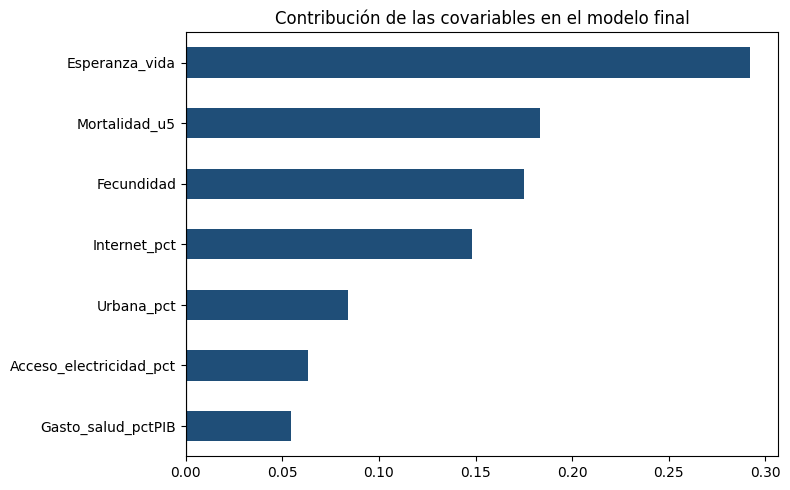

In [29]:
# Importancia o efecto de variables del modelo seleccionado
if hasattr(mejor, "feature_importances_"):
    importancia = pd.Series(mejor.feature_importances_, index=covariables, name="Importancia")
elif hasattr(mejor, "coef_"):
    importancia = pd.Series(np.ravel(mejor.coef_), index=covariables, name="Coeficiente")
else:
    importancia = pd.Series(dtype=float, name="Importancia")

if not importancia.empty:
    display(importancia.reindex(importancia.abs().sort_values(ascending=False).index).to_frame())
    importancia.sort_values().plot(kind="barh", color="#1F4E78")
    plt.axvline(0, color="black", linewidth=0.8)
    plt.title("Contribución de las covariables en el modelo final")
    plt.tight_layout()
    plt.show()


## 5. Aprendizaje no supervisado

Ahora agrupo los países usando solo las covariables, sin la variable de ingreso. Estandarizo todas las covariables porque el clúster trabaja con distancias.


In [30]:
# La variable respuesta y los indicadores monetarios quedan excluidos del clustering.
imputer_cluster = SimpleImputer(strategy="median")
Xc_imputado = imputer_cluster.fit_transform(df[covariables])
scaler_cluster = StandardScaler()
Xc = scaler_cluster.fit_transform(Xc_imputado)
print("Matriz para clustering:", Xc.shape)


Matriz para clustering: (217, 7)


### Cantidad de grupos

Elijo el número de grupos combinando dos criterios, el método del codo sobre la inercia y el coeficiente de silueta.


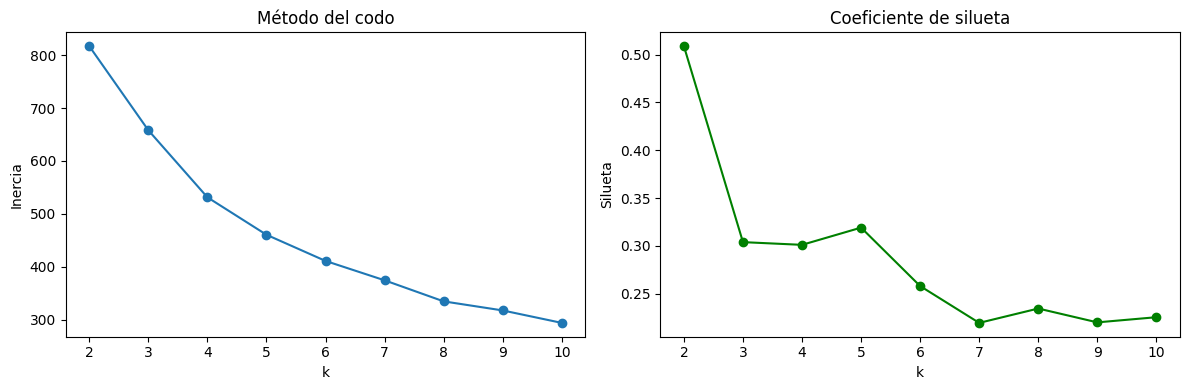

In [31]:
inercias, siluetas, ks = [], [], range(2, 11)
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Xc)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(Xc, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(ks), inercias, "o-"); ax[0].set_title("Método del codo")
ax[0].set_xlabel("k"); ax[0].set_ylabel("Inercia")
ax[1].plot(list(ks), siluetas, "o-", color="green"); ax[1].set_title("Coeficiente de silueta")
ax[1].set_xlabel("k"); ax[1].set_ylabel("Silueta")
plt.tight_layout(); plt.show()

El codo y la silueta sugieren una cantidad reducida de grupos. Ajusto K-means con el k elegido y también muestro un dendrograma del clúster jerárquico como respaldo visual.


Cantidad de clústeres seleccionada por silueta: k=2


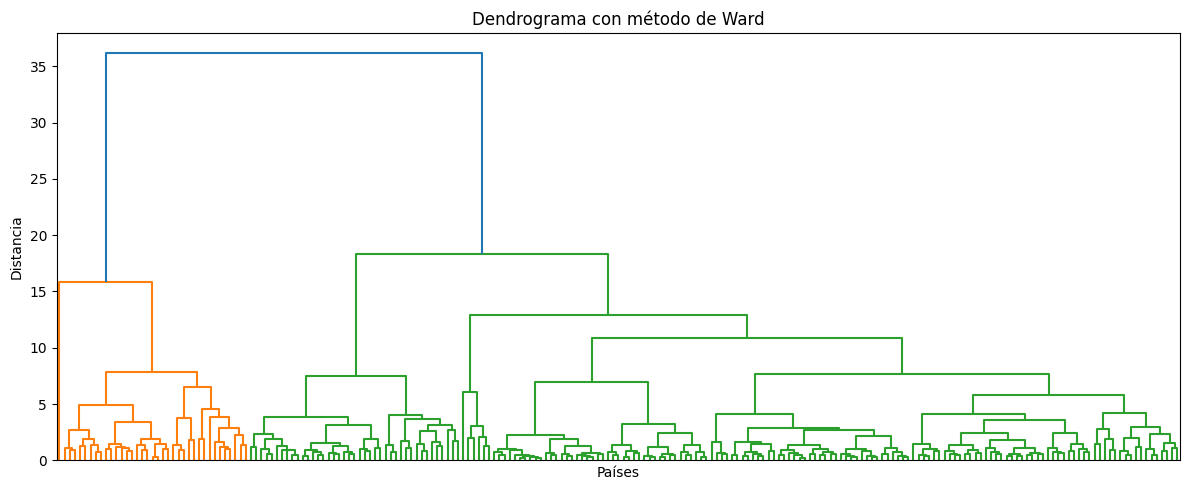

In [32]:
# Se elige el k con mayor silueta entre los valores evaluados.
# El gráfico del codo se utiliza como verificación complementaria.
K = list(ks)[int(np.argmax(siluetas))]
print(f"Cantidad de clústeres seleccionada por silueta: k={K}")

km = KMeans(n_clusters=K, n_init=20, random_state=RANDOM_STATE).fit(Xc)
df["Cluster"] = km.labels_

Z = linkage(Xc, method="ward")
plt.figure(figsize=(12, 5))
dendrogram(Z, no_labels=True, color_threshold=None)
plt.title("Dendrograma con método de Ward")
plt.xlabel("Países")
plt.ylabel("Distancia")
plt.tight_layout()
plt.show()


Proyecto los países en dos dimensiones con PCA para visualizar los grupos.


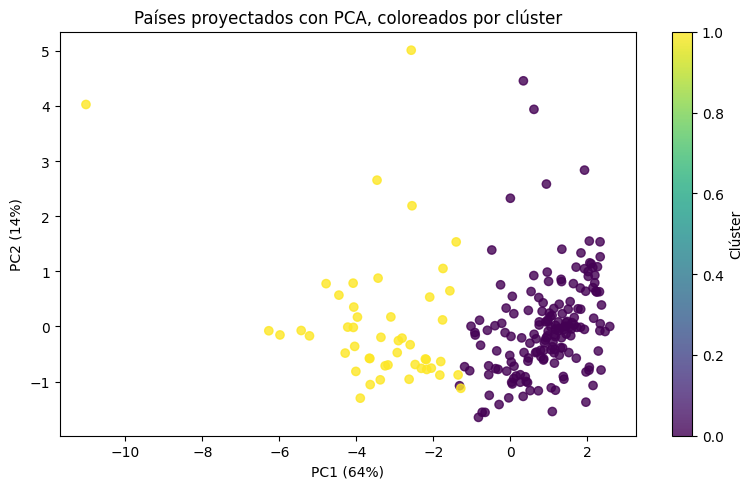

In [33]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(Xc)
plt.figure()
sc = plt.scatter(coords[:, 0], coords[:, 1], c=df["Cluster"], cmap="viridis", alpha=0.8)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)")
plt.title("Países proyectados con PCA, coloreados por clúster")
plt.colorbar(sc, label="Clúster"); plt.tight_layout(); plt.show()

### Descripción de los grupos

Describo cada clúster por el promedio de sus indicadores, incluyendo el PIB per cápita solo para caracterizarlos.


In [34]:
perfil = df.groupby("Cluster")[covariables + ["PIB_per_capita"]].mean()
perfil["N_paises"] = df.groupby("Cluster").size()
perfil.T

Cluster,0,1
Esperanza_vida,76.10,62.59
Fecundidad,1.89,4.25
Urbana_pct,68.72,39.94
Internet_pct,82.16,31.71
Mortalidad_u5,13.41,69.76
Gasto_salud_pctPIB,7.17,5.81
Acceso_electricidad_pct,98.28,49.95
PIB_per_capita,"26,542.16","1,734.86"
N_paises,169.00,48.00


### Interpretación comparativa de los clústeres

Los promedios originales permiten describir cada grupo en unidades comprensibles. Para reconocer qué variables distinguen con mayor intensidad a cada clúster, también se presentan centroides estandarizados: valores positivos están sobre el promedio global y valores negativos bajo el promedio global.


,N_paises,Porcentaje
Cluster,,
0,169,77.90
1,48,22.10


,Esperanza_vida,Fecundidad,Urbana_pct,Internet_pct,Mortalidad_u5,Gasto_salud_pctPIB,Acceso_electricidad_pct
Cluster 0,0.38,-0.43,0.27,0.43,-0.34,0.09,0.46
Cluster 1,-1.33,1.51,-0.96,-1.50,1.18,-0.31,-1.64


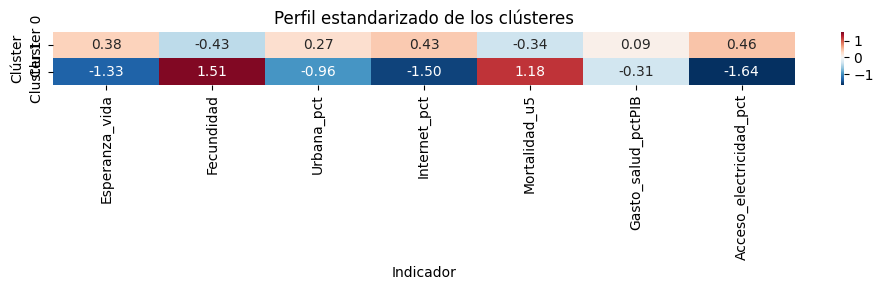

In [35]:
centroides_z = pd.DataFrame(
    km.cluster_centers_,
    columns=covariables,
    index=[f"Cluster {i}" for i in range(K)]
)

tamanos = df["Cluster"].value_counts().sort_index()
porcentajes = df["Cluster"].value_counts(normalize=True).sort_index().mul(100)
resumen_clusters = pd.DataFrame({"N_paises": tamanos, "Porcentaje": porcentajes.round(1)})

display(resumen_clusters)
display(centroides_z.round(2))

plt.figure(figsize=(10, max(3, K * 0.7)))
sns.heatmap(centroides_z, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Perfil estandarizado de los clústeres")
plt.xlabel("Indicador")
plt.ylabel("Clúster")
plt.tight_layout()
plt.show()


### Contraste con la clasificación oficial de ingreso

Cruzo los grupos obtenidos con el nivel de ingreso del Banco Mundial. Aquí es donde aparece la información no evidente, los países que caen en un clúster que no corresponde al cajón donde los pone su nivel de ingreso.


In [36]:
tabla = pd.crosstab(df["Cluster"], df["Ingreso"])
tabla

Ingreso,High income,Low income,Lower middle income,Upper middle income
Cluster,,,,
0,86,2,24,57
1,0,23,23,2


In [37]:
# Ejemplos de países cuyo perfil los acerca a un grupo distinto al de su ingreso
resumen = df[["Ingreso", "Cluster", "PIB_per_capita", "Esperanza_vida", "Internet_pct"]]
resumen.sort_values(["Cluster", "Ingreso"]).head(20)

,Ingreso,Cluster,PIB_per_capita,Esperanza_vida,Internet_pct
Pais,,,,,
Aruba,High income,0,"31,000.57",76.23,NaN
Andorra,High income,0,"42,414.06",84.02,94.05
United Arab Emirates,High income,0,"50,759.76",80.49,100.00
American Samoa,High income,0,"18,017.46",72.75,NaN
Antigua and Barbuda,High income,0,"20,003.39",77.48,71.92
Australia,High income,0,"65,169.52",83.20,96.12
Austria,High income,0,"52,336.77",81.30,93.61
Belgium,High income,0,"50,639.03",81.75,94.01
Bulgaria,High income,0,"13,999.91",74.16,79.13


### Exportación de la base analítica

Se guarda una copia de la base utilizada para acompañar la entrega y facilitar la reproducibilidad.


In [38]:
df.to_csv("TareaFinal_base_analitica_2022.csv", encoding="utf-8-sig")
print("Base exportada: TareaFinal_base_analitica_2022.csv")


Base exportada: TareaFinal_base_analitica_2022.csv


## 6. Limitaciones y reproducibilidad

- El análisis es transversal y utiliza información correspondiente a 2022, por lo que no permite establecer relaciones causales ni representar cambios entre años.
- La cobertura de algunos indicadores no es completa. La imputación por mediana facilita el modelado, pero reduce la variabilidad y no reemplaza observaciones reales.
- La clasificación binaria simplifica las cuatro categorías oficiales de ingreso. Por ello, el resultado debe interpretarse como una distinción entre ingreso alto y resto, no como una clasificación completa del desarrollo.
- Las agrupaciones dependen de las variables seleccionadas, el escalamiento y el criterio para elegir k. Los clústeres describen similitudes estadísticas y no categorías naturales definitivas.
- Para reproducir el notebook se requiere conexión a Internet durante la extracción desde la API. Después de ejecutar la extracción, se recomienda conservar el archivo de datos generado junto con la entrega.

## 7. Referencias

World Bank. (s. f.). *World Development Indicators*. World Bank Open Data.

World Bank. (s. f.). *World Bank API documentation*. World Bank Data Help Desk.

Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.


## 8. Conclusiones

El trabajo permitió abordar el problema desde dos perspectivas complementarias. En el análisis supervisado, la clasificación del nivel de ingreso se construyó únicamente con indicadores no monetarios, evitando utilizar el PIB per cápita como predictor y reduciendo así el riesgo de circularidad. La comparación de modelos se efectuó mediante validación cruzada sobre el conjunto de entrenamiento, mientras que el conjunto de prueba se reservó para la evaluación final. Esta separación fortalece la validez de la selección y permite interpretar con mayor confianza la capacidad de generalización observada en las métricas.

Las métricas de clasificación deben leerse en conjunto. La exactitud balanceada, el F1, el recall y el ROC-AUC complementan a la exactitud y resultan especialmente relevantes cuando los grupos de ingreso no tienen el mismo tamaño. La matriz de confusión permite distinguir los errores asociados a países de ingreso alto clasificados como resto y viceversa. La contribución de las variables del modelo final muestra qué dimensiones de salud, conectividad, urbanización y acceso a servicios aportan más a la separación entre clases.

En el análisis no supervisado, la variable de ingreso fue excluida antes de estandarizar y agrupar. La cantidad de clústeres se determinó mediante un criterio explícito, utilizando la silueta y verificando el comportamiento de la inercia. Los centroides estandarizados permiten reconocer perfiles relativos de desarrollo y diferenciar los grupos según sus indicadores más característicos. El cruce posterior con la clasificación oficial no interviene en la formación de los clústeres, sino que sirve para evaluar coincidencias y divergencias.

En conjunto, los resultados muestran que el nivel de ingreso está acompañado por patrones multidimensionales y que dos países clasificados en una misma categoría económica pueden presentar perfiles sociales y sanitarios distintos. Del mismo modo, países de categorías oficiales diferentes pueden aparecer próximos cuando se consideran únicamente variables no monetarias. Este contraste constituye la principal información no evidente obtenida mediante el análisis.

### Limitaciones

- La base corresponde a un único año y no permite establecer relaciones causales ni evolución temporal.
- La disponibilidad desigual de indicadores puede reducir el número de países analizados y afectar su representatividad.
- Los valores atípicos pueden ser observaciones reales, errores de medición o diferencias estructurales y requieren revisión contextual.
- K-means supone grupos aproximadamente compactos y utiliza distancia euclidiana; otras estructuras podrían requerir métodos alternativos.
- La categoría de ingreso es una simplificación binaria para el modelado y no representa toda la diversidad económica entre países.

### Trabajo futuro

Se recomienda ampliar el análisis a varios años, evaluar imputación dentro de pipelines, incorporar ajuste de hiperparámetros, comparar otros algoritmos de clustering y analizar en profundidad los países cuya clasificación oficial difiere del perfil obtenido a partir de los indicadores.

## Referencias

Banco Mundial. (s. f.). *World Development Indicators* [Base de datos]. https://data.worldbank.org

Banco Mundial. (s. f.). *World Bank API documentation*. https://datahelpdesk.worldbank.org/knowledgebase/topics/125589-developer-information

Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.
